In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_condition_distribution(dataset_dir: str):
    """
    Loads X.csv and y.csv from the given directory and plots their distributions.
    Highlights class separation using the most informative features and PCA.
    
    Parameters
    ----------
    dataset_dir : str
        Path to the specific condition folder (e.g., "../data/synthetic_data/tau_0.10_d_2.0_n_1000")
    """
    x_path = os.path.join(dataset_dir, "X.csv")
    y_path = os.path.join(dataset_dir, "y.csv")
    
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        raise FileNotFoundError(f"Could not find X.csv or y.csv in {dataset_dir}")
        
    # Load data
    X = pd.read_csv(x_path)
    y = pd.read_csv(y_path).squeeze()
    
    # Merge into a single DataFrame for easier plotting with Seaborn
    df = X.copy()
    # Convert labels to strings for categorical handling in plots
    df['label'] = y.map({0: '0 (Majority)', 1: '1 (Minority)'}) 
    
    # Define a clean color palette
    palette = {'0 (Majority)': '#1f77b4', '1 (Minority)': '#ff7f0e'}
    
    # Setup the figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    condition_name = os.path.basename(dataset_dir.rstrip('/\\'))
    fig.suptitle(f"Distribution Analysis: {condition_name}", fontsize=16, fontweight='bold', y=1.05)
    
    # ─── Panel 1: Density of Feature 1 ──────────────────────────────
    sns.kdeplot(
        data=df, x='feature_1', hue='label', fill=True, 
        palette=palette, alpha=0.5, ax=axes[0], common_norm=False, linewidth=2
    )
    axes[0].set_title("Density of feature_1 (Strongest Signal)")
    axes[0].set_xlabel("feature_1 value")
    axes[0].set_ylabel("Density")
    
    # ─── Panel 2: Scatter of Top 2 Features ─────────────────────────
    # Plot majority class first so minority class points sit on top
    sns.scatterplot(
        data=df.sort_values('label'), x='feature_1', y='feature_2', 
        hue='label', palette=palette, alpha=0.7, edgecolor='w', s=50, ax=axes[1]
    )
    axes[1].set_title("Feature 1 vs Feature 2")
    
    # ─── Panel 3: PCA Projection of All Features ────────────────────
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca['label'] = df['label']
    
    sns.scatterplot(
        data=df_pca.sort_values('label'), x='PC1', y='PC2', 
        hue='label', palette=palette, alpha=0.7, edgecolor='w', s=50, ax=axes[2]
    )
    
    explained_var = pca.explained_variance_ratio_.sum()
    axes[2].set_title(f"PCA Projection (2 Components)\nExplained Variance: {explained_var:.1%}")
    axes[2].set_xlabel("Principal Component 1")
    axes[2].set_ylabel("Principal Component 2")
    
    plt.tight_layout()
    plt.show()

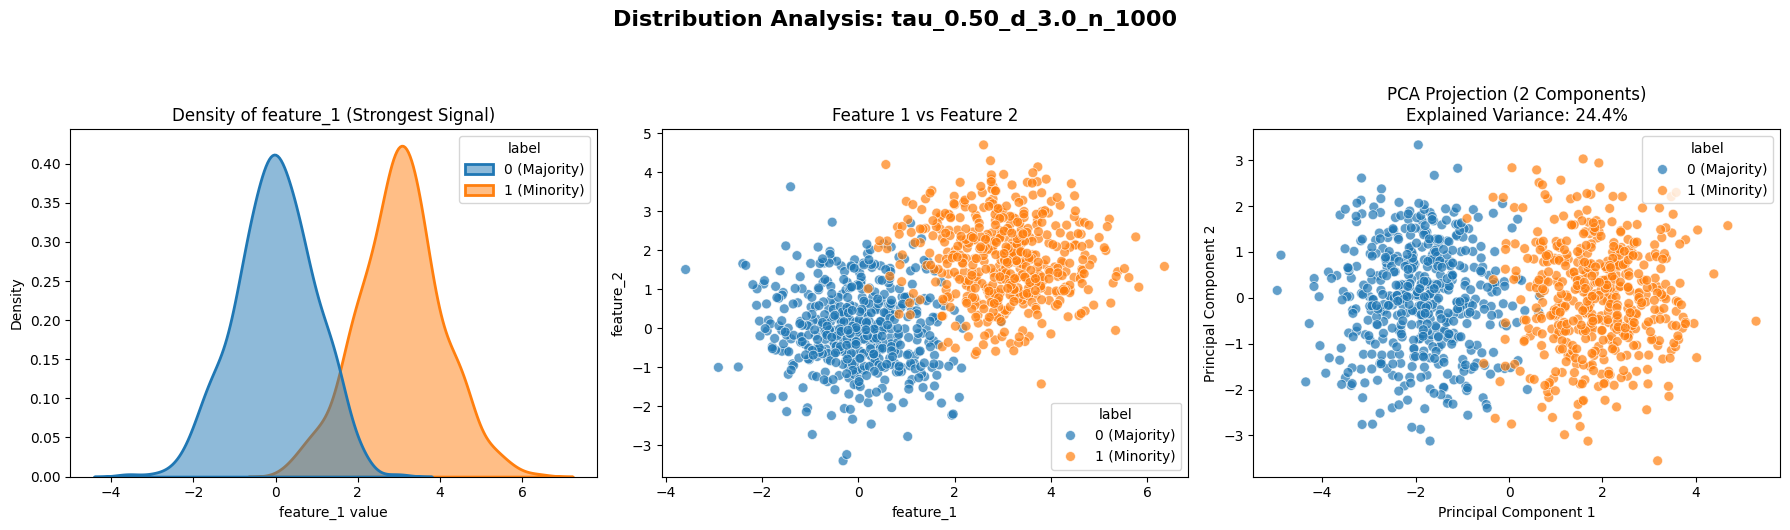

In [15]:
tau = "0.50"
d = "3.0"
n = "1000"

# Assuming you already ran generate_all_conditions()
target_folder = f"../data/synthetic_data/tau_{tau}_d_{d}_n_{n}"

# Plot the distribution
plot_condition_distribution(target_folder)

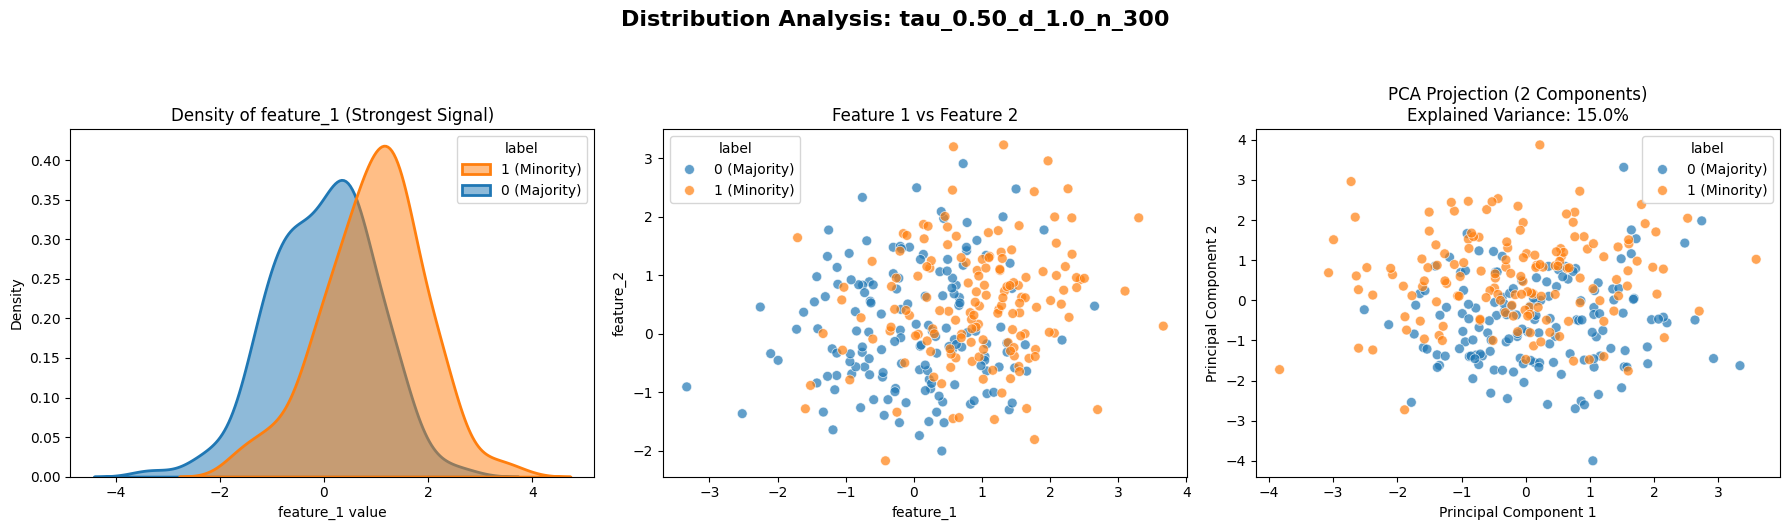

In [12]:
tau = "0.50"
d = "1.0"
n = "300"

# Assuming you already ran generate_all_conditions()
target_folder = f"../data/synthetic_data/tau_{tau}_d_{d}_n_{n}"

# Plot the distribution
plot_condition_distribution(target_folder)